# Financial Fraud and Anomaly Detection - Visual Analysis
This notebook provides practical visualizations based on the cleaned dataset `data_v3.csv` to identify patterns related to fraudulent transactions.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Load the cleaned dataset
df = pd.read_csv("data_v3.csv", index_col=0)
df.head()

### 1. Target Variable Distribution (Fraud vs. Non-Fraud)
Understanding the class imbalance is crucial for fraud detection.

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='is_fraud', data=df, hue='is_fraud', palette='viridis', legend=False)
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud? (0 = No, 1 = Yes)')
plt.ylabel('Number of Transactions')

# Add percentage labels
total = len(df['is_fraud'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), size = 12)

plt.show()

### 2. Transaction Amount Analysis
Are fraudulent transactions generally higher in value?

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='amount', hue='is_fraud', kde=True, bins=50, palette='magma')
plt.title('Distribution of Transaction Amounts by Fraud Status')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

### 3. Amount Boxplot
Visualizing outliers and median values for fraud vs. non-fraud.

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amount', data=df, palette='Set2', hue='is_fraud', legend=False)
plt.title('Transaction Amount Boxplot by Fraud Status')
plt.xlabel('Is Fraud?')
plt.ylabel('Amount')
plt.show()

### 4. Fraud Rate by Merchant Category
Which categories are most susceptible to fraud?

In [ ]:
merchant_fraud = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False).reset_index()
merchant_fraud['is_fraud_pct'] = merchant_fraud['is_fraud'] * 100

plt.figure(figsize=(12, 6))
sns.barplot(x='is_fraud_pct', y='merchant_category', data=merchant_fraud, palette='coolwarm', hue='merchant_category', legend=False)
plt.title('Fraud Rate (%) by Merchant Category')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Merchant Category')
plt.show()

### 5. Correlation Heatmap
Identifying which features have the strongest relationship with fraud.

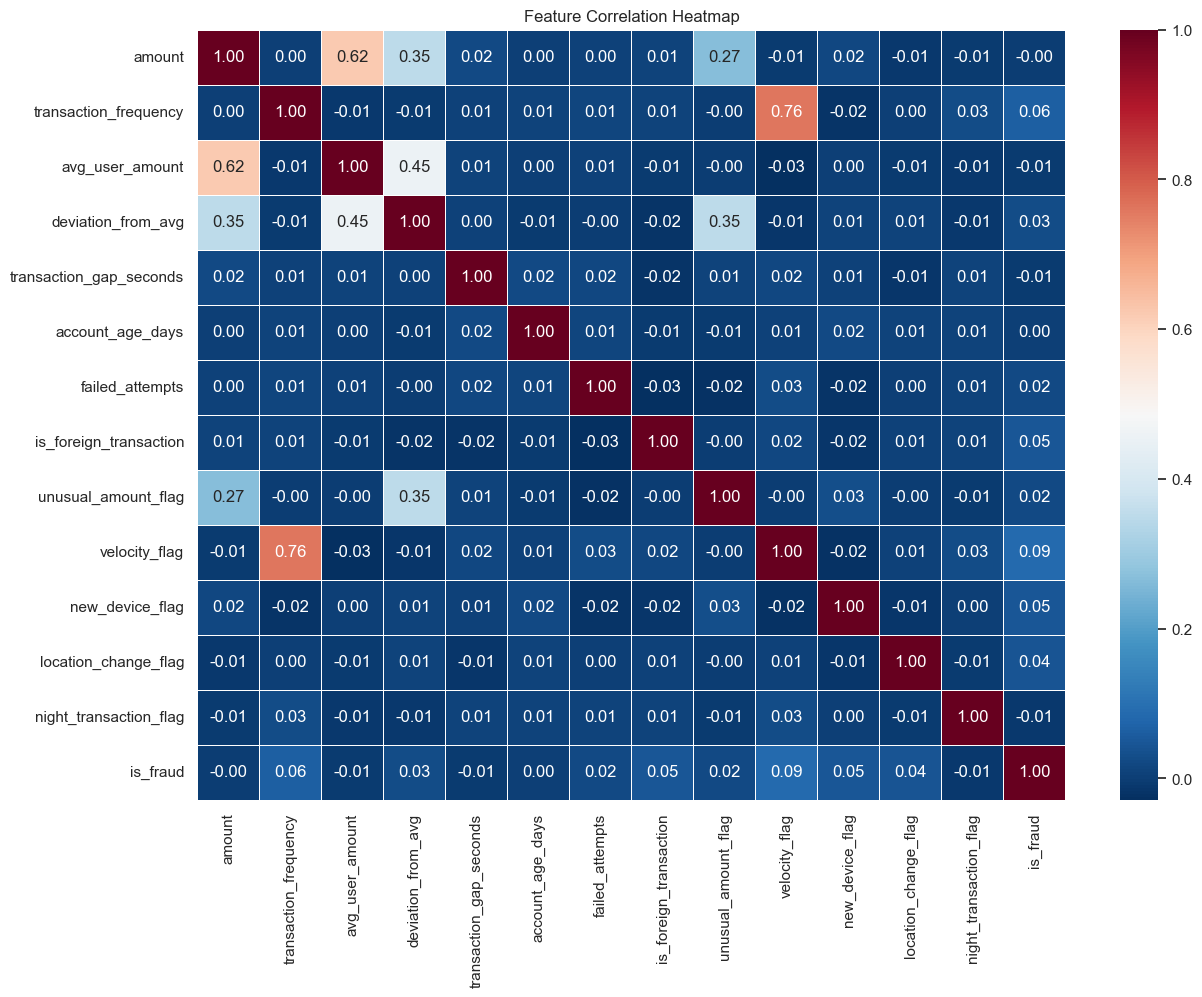

In [28]:
# Select numerical columns only
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### 6. Failed Attempts vs. Fraud
Do multiple failed login/transaction attempts signal potential fraud?

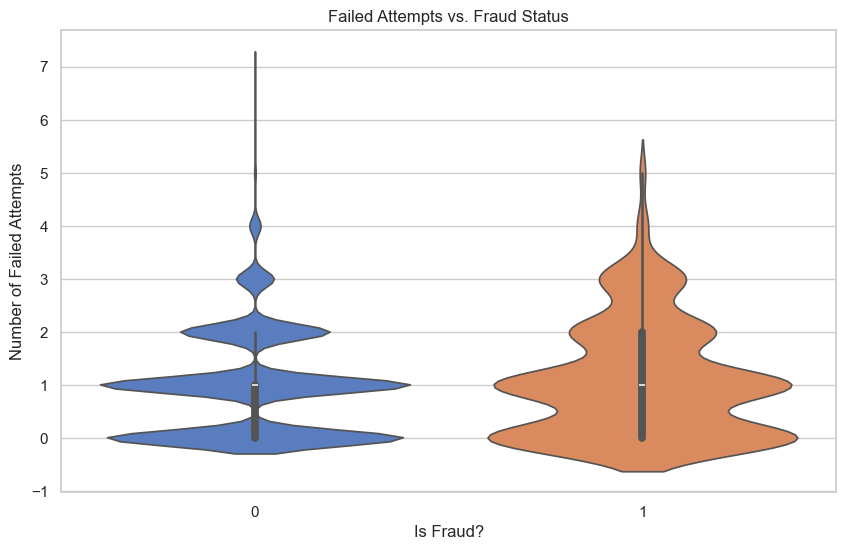

In [24]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='is_fraud', y='failed_attempts', data=df, hue='is_fraud', palette='muted', legend=False)
plt.title('Failed Attempts vs. Fraud Status')
plt.xlabel('Is Fraud?')
plt.ylabel('Number of Failed Attempts')
plt.show()

### 7. Transaction Type Distribution (Matplotlib Pie Chart)
Breakdown of how users are moving money.

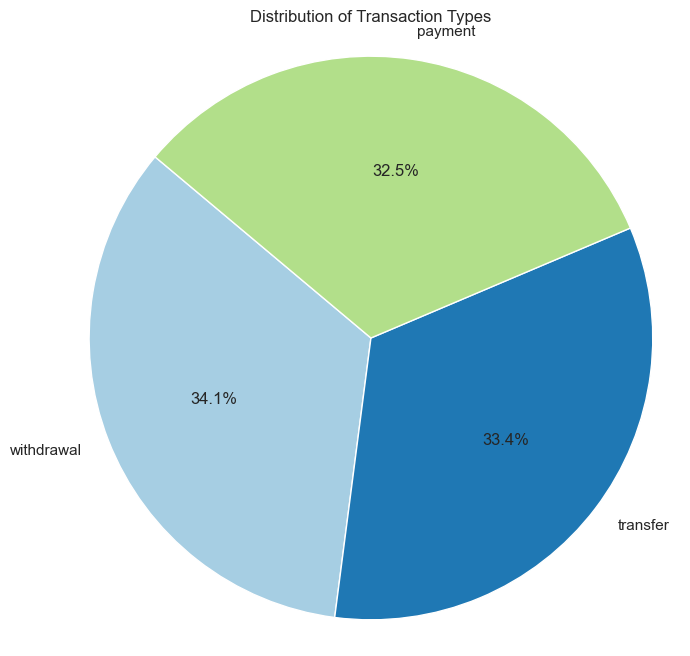

In [25]:
type_counts = df['transaction_type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Transaction Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### 8. Amount vs. Account Age (Matplotlib Scatter)
Investigating if newer accounts have different transaction behaviors.

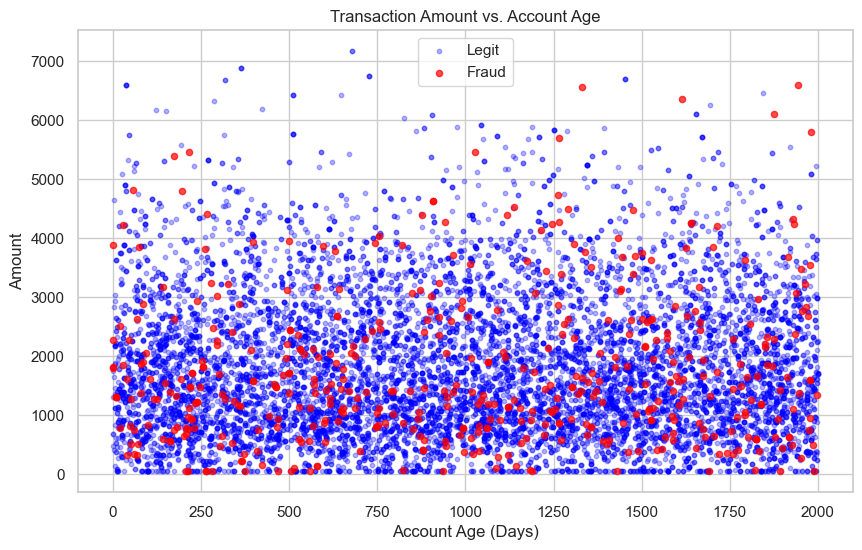

In [26]:
plt.figure(figsize=(10, 6))
fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]

plt.scatter(legit['account_age_days'], legit['amount'], alpha=0.3, label='Legit', c='blue', s=10)
plt.scatter(fraud['account_age_days'], fraud['amount'], alpha=0.7, label='Fraud', c='red', s=20)

plt.title('Transaction Amount vs. Account Age')
plt.xlabel('Account Age (Days)')
plt.ylabel('Amount')
plt.legend()
plt.show()

### 9. Device Type Usage (Matplotlib Bar Chart)
Comparing which devices are most commonly used for transactions.

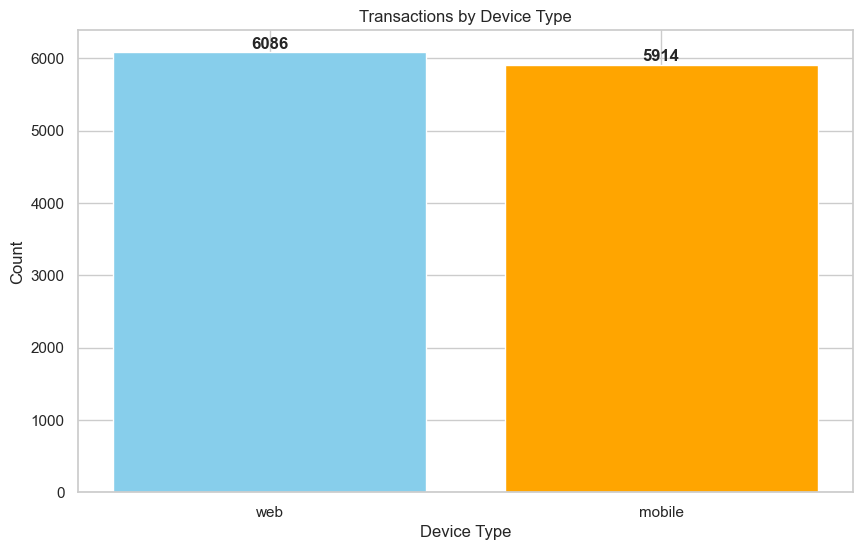

In [27]:
device_counts = df['device_type'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(device_counts.index, device_counts.values, color=['skyblue', 'orange'])
plt.title('Transactions by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Count')

# Adding data labels
for i, v in enumerate(device_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.show()